In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import polars as pl

inicial = (
    pl.scan_parquet(r"C:\Users\diogo.durao\Documents\covid_sp.parquet")
    .select([
        "paciente_idade",
        "paciente_dataNascimento",
        "paciente_enumSexoBiologico",
        "paciente_endereco_nmMunicipio",
        "paciente_endereco_uf",
        "vacina_dataAplicacao",
        "vacina_fabricante_nome",
        "vacina_nome"
    ])
    .with_columns(
        pl.col("paciente_idade").cast(pl.Int64, strict=False),
        pl.col("paciente_dataNascimento").str.to_date("%Y-%m-%d", strict=False),
        pl.col("vacina_dataAplicacao").str.to_date("%Y-%m-%d", strict=False)
    )
)

display(inicial.head(5).collect())

paciente_idade,paciente_dataNascimento,paciente_enumSexoBiologico,paciente_endereco_nmMunicipio,paciente_endereco_uf,vacina_dataAplicacao,vacina_fabricante_nome,vacina_nome
i64,date,str,str,str,date,str,str
32,1989-05-29,"""F""","""GUARULHOS""","""SP""",2022-04-05,"""JANSSEN""","""COVID-19 JANSSEN - Ad26.COV2.S"""
59,1961-09-06,"""F""","""IBITINGA""","""SP""",2021-05-31,"""ASTRAZENECA/FIOCRUZ""","""COVID-19 ASTRAZENECA/FIOCRUZ -…"
85,1936-03-09,"""M""","""SAO PAULO""","""SP""",2021-12-04,"""PFIZER""","""COVID-19 PFIZER - COMIRNATY"""
35,1985-11-22,"""M""","""SAO PAULO""","""SP""",2021-08-14,"""SINOVAC/BUTANTAN""","""COVID-19 SINOVAC/BUTANTAN - CO…"
53,1968-05-18,"""M""","""SAO PAULO""","""SP""",2021-09-14,"""PFIZER""","""COVID-19 PFIZER - COMIRNATY"""


In [3]:
"""Métricas: Média, Mediana, Moda, Variância, Desvio Padrão, Amplitude"""

# Construindo a expressão de cálculo
metricas1 = inicial.select([
    pl.col("paciente_idade").mean().alias("Média"),
    pl.col("paciente_idade").median().alias("Mediana"),

    # Moda retorna uma lista, pegamos o primeiro valor
    pl.col("paciente_idade").mode().first().alias("Moda"),

    pl.col("paciente_idade").var().alias("Variância"),

    pl.col("paciente_idade").std().alias("Desvio_Padrão"),

    (
        pl.col("paciente_idade").max() -
        pl.col("paciente_idade").min()
    ).alias("Amplitude_Total")

]).collect()

print("\n--- Estatísticas Descritivas (Idade dos Pacientes) ---")

display(metricas1)


--- Estatísticas Descritivas (Idade dos Pacientes) ---


Média,Mediana,Moda,Variância,Desvio_Padrão,Amplitude_Total
f64,f64,i64,f64,f64,i64
42.072619,42.0,40,443.113171,21.050253,224


In [4]:
'''Forma e Posição: Assimetria, Curtose e Quartis'''

metricas2 = inicial.select([
    pl.col("paciente_idade").quantile(0.25).alias("Q1"),
    pl.col("paciente_idade").quantile(0.50).alias("Q2"),
    pl.col("paciente_idade").quantile(0.75).alias("Q3"),

    pl.col("paciente_idade").skew().alias("Assimetria"),

    pl.col("paciente_idade").kurtosis().alias("Curtose")

]).collect()

print("\n--- Quartis e Forma da Distribuição das Idades ---")

display(metricas2)

# Análise rápida da Assimetria
assimetria = metricas2["Assimetria"][0]

print(f"\nInterpretação da Assimetria ({assimetria:.2f}):")

if -0.5 <= assimetria <= 0.5:
    print("-> Distribuição Simétrica (idades bem balanceadas)")

elif assimetria > 0.5:
    print("-> Assimétrica Positiva (existem pacientes com idades muito altas puxando a média)")

else:
    print("-> Assimétrica Negativa (maior concentração em idades mais altas)")


--- Quartis e Forma da Distribuição das Idades ---


Q1,Q2,Q3,Assimetria,Curtose
f64,f64,f64,f64,f64
26.0,42.0,58.0,0.078079,-0.777309



Interpretação da Assimetria (0.08):
-> Distribuição Simétrica (idades bem balanceadas)


In [5]:
'''Outliers'''

Q1 = metricas2["Q1"][0]
Q3 = metricas2["Q3"][0]

IQR = Q3 - Q1

limite_inferior = Q1 - (1.5 * IQR)
limite_superior = Q3 + (1.5 * IQR)

print(f"\nLimites para Outliers: Inferior ({limite_inferior}) | Superior ({limite_superior})")

outliers = inicial.filter(
    (pl.col("paciente_idade") < limite_inferior) |
    (pl.col("paciente_idade") > limite_superior)

).select([
    "paciente_idade",
    "paciente_endereco_nmMunicipio",
    "paciente_enumSexoBiologico"
    
]).collect()

print(f"Quantidade de pacientes considerados Outliers: {outliers.height}")

print("Exemplos de idades discrepantes:")

display(outliers.head())


Limites para Outliers: Inferior (-22.0) | Superior (106.0)
Quantidade de pacientes considerados Outliers: 431
Exemplos de idades discrepantes:


paciente_idade,paciente_endereco_nmMunicipio,paciente_enumSexoBiologico
i64,str,str
117,"""CAMPINAS""","""M"""
121,"""CAMPINAS""","""F"""
108,"""ITAPIRA""","""F"""
107,"""CERQUILHO""","""F"""
121,"""OSASCO""","""F"""


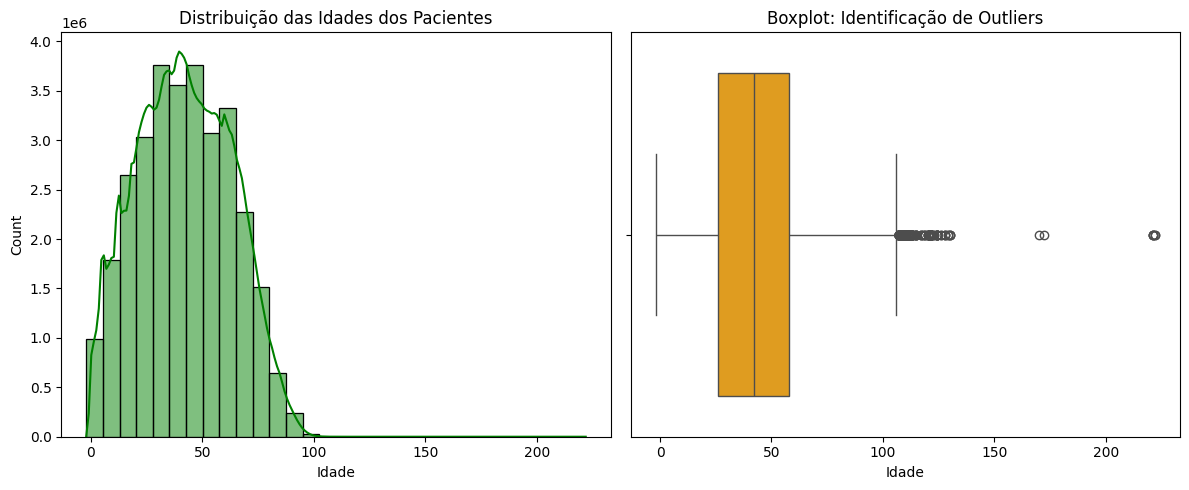

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

"""Visualização"""

# Coletando a coluna para plotagem
visual = inicial.select("paciente_idade").collect().to_series()

plt.figure(figsize=(12, 5))

# Histograma
plt.subplot(1, 2, 1)

sns.histplot(
    visual,
    bins=30,
    kde=True,
    color='green'
)

plt.title('Distribuição das Idades dos Pacientes')
plt.xlabel('Idade')

# Boxplot
plt.subplot(1, 2, 2)

sns.boxplot(
    x=visual,
    color='orange'
)

plt.title('Boxplot: Identificação de Outliers')
plt.xlabel('Idade')

plt.tight_layout()
plt.show()

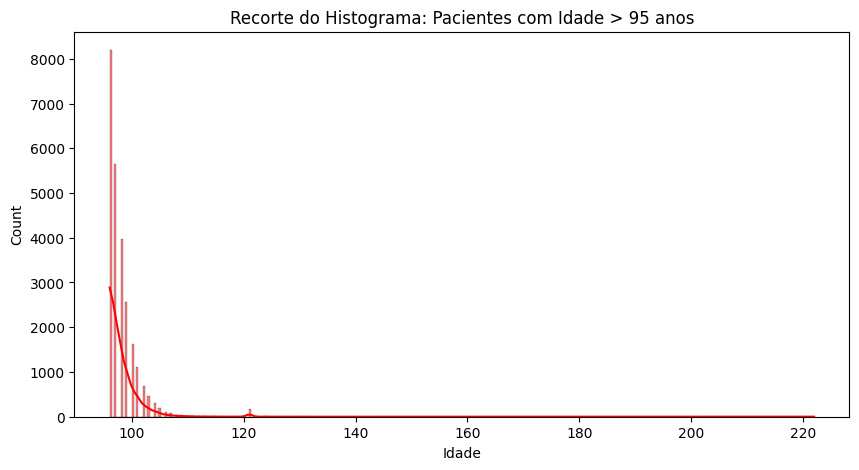

In [7]:
visual_superiores = (
    inicial
    .filter(pl.col("paciente_idade") > 95)
    .select("paciente_idade")
    .collect()
    .to_series()
)

plt.figure(figsize=(10, 5))

sns.histplot(
    visual_superiores,
    kde=True,
    color='red'
)

plt.title('Recorte do Histograma: Pacientes com Idade > 95 anos')

plt.xlabel('Idade')

plt.show()

In [8]:
'''Correlação de Pearson'''

# 1. Criar o DataFrame agregado por município
df_municipios = inicial.group_by("paciente_endereco_nmMunicipio").agg([

    pl.len().alias("Qtd_Pacientes"),  # Variável X

    pl.col("paciente_idade")
    .mean()
    .alias("Idade_Media")             # Variável Y

])

# 2. Calcular a Correlação de Pearson
correlacao = df_municipios.select(

    pl.corr(
        "Qtd_Pacientes",
        "Idade_Media",
        method="pearson"
    ).alias("r")

).collect()

r = correlacao["r"][0]
r2 = r**2

print(f"\n--- Análise de Correlação por Município ---")

print(f"Coeficiente de Pearson (r): {r:.4f}")

print(f"Coeficiente de Determinação (r²): {r2:.4f}")

# Interpretação
if abs(r) < 0.3:
    print("Conclusão: Correlação FRACA. A quantidade de pacientes no município não influencia muito a idade média.")

elif abs(r) > 0.7:
    print("Conclusão: Correlação FORTE.")

else:
    print("Conclusão: Correlação MODERADA.")


--- Análise de Correlação por Município ---
Coeficiente de Pearson (r): 0.0387
Coeficiente de Determinação (r²): 0.0015
Conclusão: Correlação FRACA. A quantidade de pacientes no município não influencia muito a idade média.


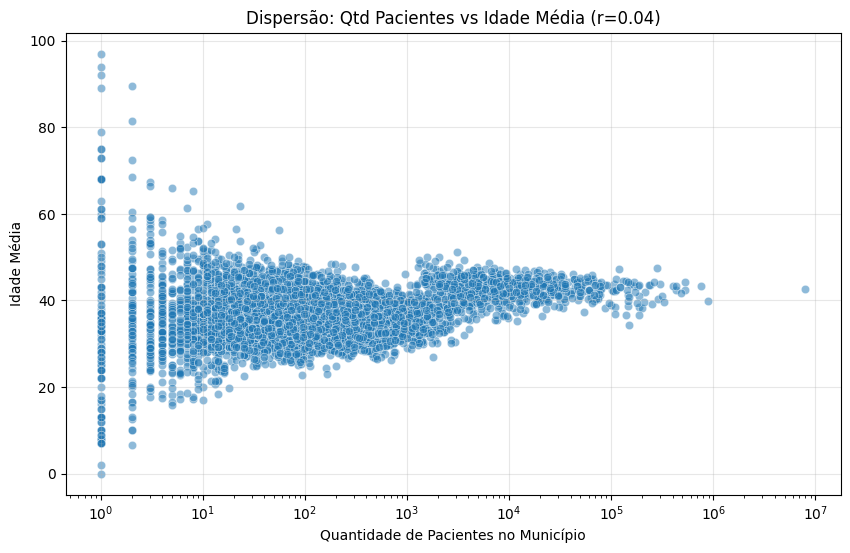

In [9]:
'''Gráfico de Dispersão'''

# Coletando os dados agregados para o gráfico
df_scatter = df_municipios.collect()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_scatter.to_pandas(),
    x="Qtd_Pacientes",
    y="Idade_Media",
    alpha=0.5
)

plt.title(f'Dispersão: Qtd Pacientes vs Idade Média (r={r:.2f})')

plt.xlabel('Quantidade de Pacientes no Município')

plt.ylabel('Idade Média')

plt.grid(True, alpha=0.3)

# Escala logarítmica ajuda a visualizar melhor
# municípios muito grandes e pequenos
plt.xscale('log')

plt.show()